In [ ]:
import pandas as pd

### 1. Building Neural Network Using Torch inbuilt functions
---
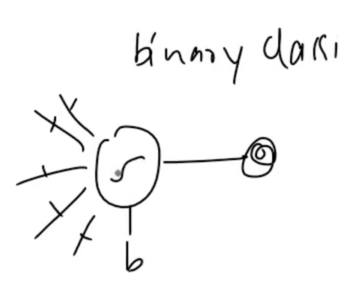

---
`5 input features` -> `forward pass get (z)` -> `Pass into sigmoid` -> `Get the Loss` -> `find gradients and update weights` 

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

In [12]:
class MyModel(nn.Module): # inherit from the nn.Module 

    def __init__(self , num_features):

        super().__init__() # Call the parent constructor
        self.linear = nn.Linear(num_features , 1) #First layer (input = num_features , output = 1)
        self.sigmoid = nn.Sigmoid() # Activation Function is Sigmoid 

    def forward(self, features):
        out = self.linear(features) #this does dot product (z)
        out = self.sigmoid(out) # this calcs sigmoid of z
        return out

In [13]:
# create data
features = torch.rand(10,5) # 10 rows, 5 cols dataset
# create model
model = MyModel(features.shape[1])

# call forward propagation
model(features) # call the forward pass to get the dot product values (these are our predictions in probabilities)

# view the weights and bias
print(model.linear.weight)
print(model.linear.bias)

Parameter containing:
tensor([[-0.2604,  0.2180,  0.0202, -0.0067, -0.1268]], requires_grad=True)
Parameter containing:
tensor([-0.2723], requires_grad=True)


### To check the summary like in keras

In [14]:
from torchinfo import summary
summary(model , input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

### Next is this one

---
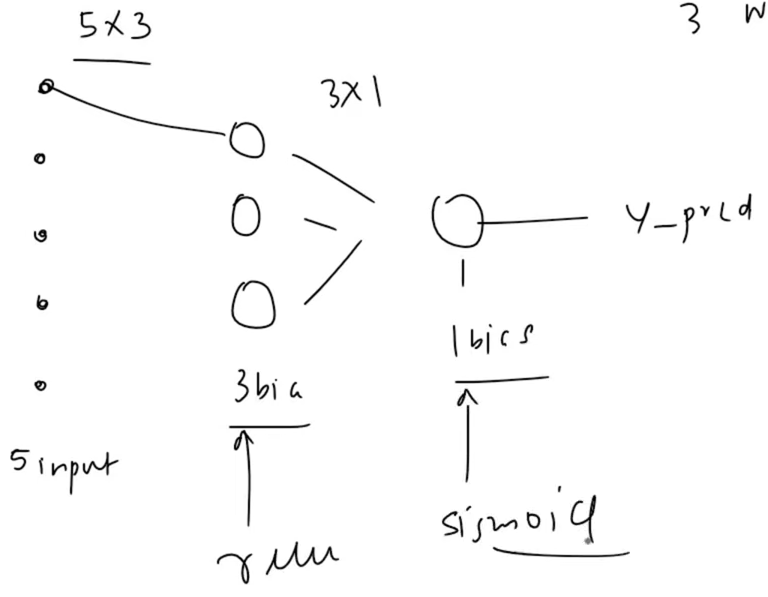

---

In [15]:
import torch.nn as nn

In [21]:
class MyModel(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential( # entire ANN architecture
            nn.Linear(num_features , 3),
            nn.ReLU(),
            nn.Linear(3 , 1),
            nn.Sigmoid()
        )

    def forward(self , features): # simplify forward pass

        out = self.network(features)
        return out

    # def back


In [ ]:
# create dataset
features = torch.rand(10,5)

# create model

model = MyModel(features.shape[1])

# forward pass

model(features)

print(model.network[0].weight) # first layer weights
print(model.network[2].weight) # second layer weights


Parameter containing:
tensor([[ 0.1753,  0.1145, -0.2605, -0.0283,  0.3148],
        [ 0.0224, -0.3316,  0.1714, -0.2314, -0.4004],
        [-0.1968,  0.4178,  0.4004, -0.2251, -0.0903]], requires_grad=True)
Parameter containing:
tensor([[ 0.2565,  0.1135, -0.0643]], requires_grad=True)


### Using the Breast Cancer dataset

In [27]:
df = pd.read_csv("breast_cancer.csv")

In [28]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [29]:
X = df.drop(['id','diagnosis','Unnamed: 32'] , axis=1)
y = df['diagnosis']

In [31]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=42)

In [35]:
# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Label Encode

encode = LabelEncoder()

y_train_enc = encode.fit_transform(y_train)
y_test_enc = encode.fit_transform(y_test)

In [46]:
# convert to tensors

X_train_tsr = torch.from_numpy(X_train_scaled).to(dtype=torch.float32)
X_test_tsr = torch.from_numpy(X_test_scaled).to(dtype=torch.float32)
y_train_tsr = torch.from_numpy(y_train_enc).to(dtype=torch.float32).view(-1,1)
y_test_tsr = torch.from_numpy(y_test_enc).to(dtype=torch.float32).view(-1,1)

In [47]:
## Build the model
import torch.nn as nn
class MyModel(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential( # entire ANN architecture
            nn.Linear(num_features , 3),
            nn.ReLU(),
            nn.Linear(3 , 1),
            nn.Sigmoid()
        )

    def forward(self , features): # simplify forward pass

        out = self.network(features)
        return out


In [48]:
learning_rate = 0.1
epochs = 100

In [ ]:
# create loss function
loss_function = nn.BCELoss()

# create model

model = MyModel(X_train_tsr.shape[1])
optimizer = torch.optim.SGD(model.parameters() , lr = learning_rate)

for epoch in range(epochs):

    # forward pass
    y_pred = model(X_train_tsr) # giving the training data features

    # loss generate/calc

    loss = loss_function(y_pred , y_train_tsr)

    # now back propagation

    loss.backward()

    # parameter update

    optimizer.step()

    # get the gradients back to zero

    optimizer.zero_grad()

    # print the loss in each epoch

    print(f'Loss at epoch {epoch+1} -> {loss}')

In [56]:
# evaluation

with torch.no_grad():
    y_pred = model.forward(X_test_tsr)
    y_pred = (y_pred>0.5).float()
    print(f'Accuracy -> {accuracy_score(y_pred , y_test_tsr)}')

Accuracy -> 0.9736842105263158
